In [147]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 💵Bank2

In [148]:
bank2headers = ['length', 'leftheight', 'rightheight', 'bottomframe', 'topframe', 'diagonal']
bank2 = pd.read_csv("bank2.dat", sep = r"\s+", header=None, names=bank2headers)
bank2.head()

,length,leftheight,rightheight,bottomframe,topframe,diagonal
0,214.8,131.0,131.1,9.0,9.7,141.0
1,214.6,129.7,129.7,8.1,9.5,141.7
2,214.8,129.7,129.7,8.7,9.6,142.2
3,214.8,129.7,129.6,7.5,10.4,142.0
4,215.0,129.6,129.7,10.4,7.7,141.8


In [149]:
bank2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   length       200 non-null    float64
 1   leftheight   200 non-null    float64
 2   rightheight  200 non-null    float64
 3   bottomframe  200 non-null    float64
 4   topframe     200 non-null    float64
 5   diagonal     200 non-null    float64
dtypes: float64(6)
memory usage: 9.5 KB


In [150]:
bank2.describe().T

,count,mean,std,min,25%,50%,75%,max
length,200.0,214.8960,0.376554,213.8,214.6,214.90,215.100,216.3
leftheight,200.0,130.1215,0.361026,129.0,129.9,130.20,130.400,131.0
rightheight,200.0,129.9565,0.404072,129.0,129.7,130.00,130.225,131.1
bottomframe,200.0,9.4175,1.444603,7.2,8.2,9.10,10.600,12.7
topframe,200.0,10.6505,0.802947,7.7,10.1,10.60,11.200,12.3
diagonal,200.0,140.4835,1.152266,137.8,139.5,140.45,141.500,142.4


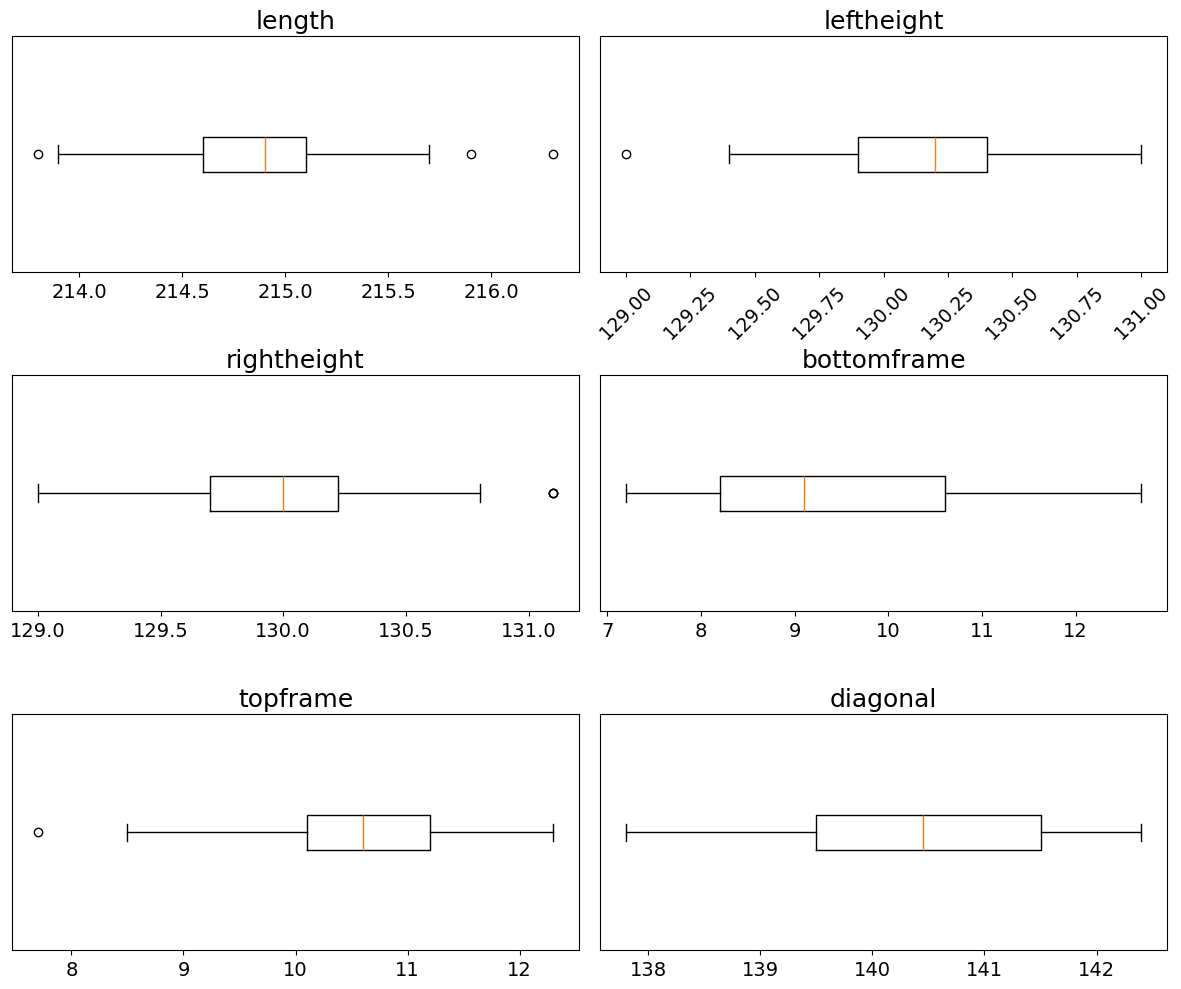

In [151]:
import matplotlib.pyplot as plt

columns = ['length', 'leftheight', 'rightheight', 'bottomframe', 'topframe', 'diagonal']
fig, ax = plt.subplots(3, 2, figsize=(12, 10))
axes = ax.flatten()

for i, col in enumerate(columns):
    axes[i].boxplot(x=bank2[col], vert=False)
    axes[i].set_title(col, fontsize=18)
    axes[i].set_yticks([])
    if i == 1:
        axes[i].tick_params(axis='x', labelsize=13.5, rotation=45) # x 軸刻度字體大小
    else:
        axes[i].tick_params(axis='x', labelsize=14) # x 軸刻度字體大小

plt.tight_layout()
plt.show()


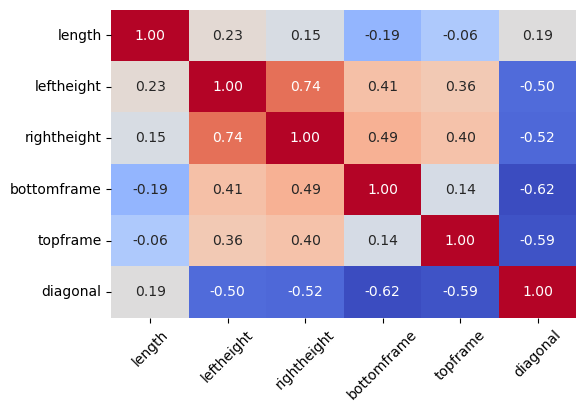

In [152]:
plt.figure(figsize=(6, 4))
sns.heatmap(bank2.corr(), fmt='.2f', annot=True, cmap='coolwarm', cbar=False)
plt.xticks(rotation=45)
plt.show()

In [153]:
bank2_scaled = (bank2-bank2.mean())/bank2.std()
cov_matrix = np.cov(bank2_scaled, rowvar=False)
eigenvalue, eigenvector = np.linalg.eig(cov_matrix)
bank2vector = np.dot(bank2_scaled, eigenvector)

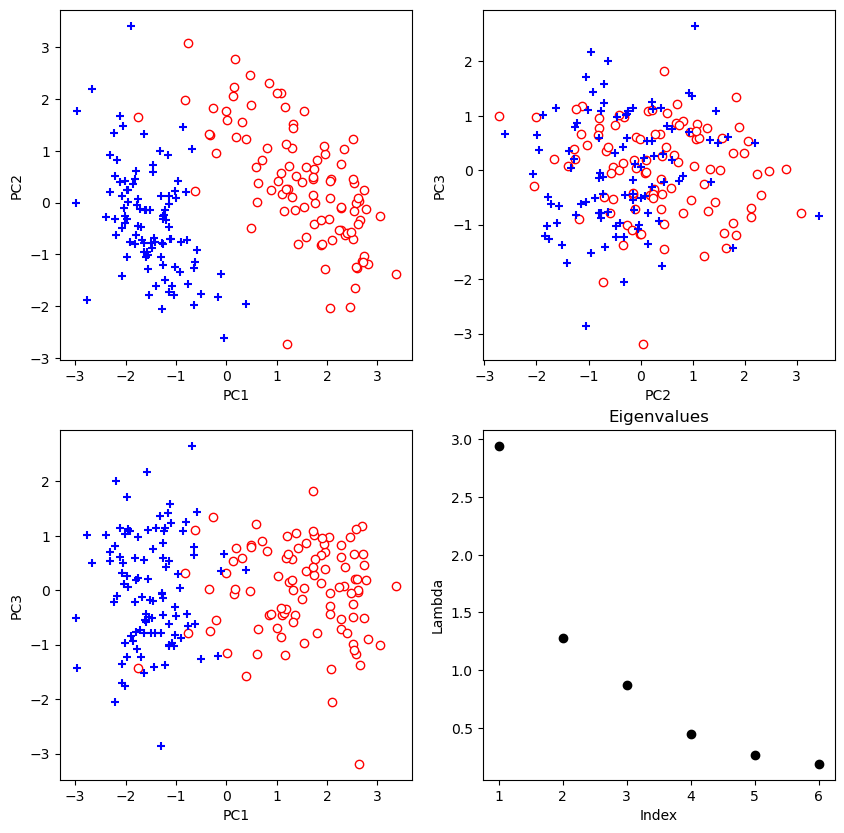

In [154]:
fig, axs = plt.subplots(2,2, figsize=(10, 10))
axs[0, 0].scatter(bank2vector[:100, 0], bank2vector[:100, 1], edgecolor='r', marker='o', facecolors='w')
axs[0, 0].scatter(bank2vector[100:, 0], bank2vector[100:, 1], c='b', marker='+')
axs[0, 0].set_xlabel('PC1')
axs[0, 0].set_ylabel('PC2')

axs[0, 1].scatter(bank2vector[:100, 1], bank2vector[:100, 2], edgecolor='r', marker='o', facecolors='w')
axs[0, 1].scatter(bank2vector[100:, 1], bank2vector[100:, 2], c='b', marker='+')
axs[0, 1].set_xlabel('PC2')
axs[0, 1].set_ylabel('PC3')

axs[1, 0].scatter(bank2vector[:100, 0], bank2vector[:100, 2], edgecolor='r', marker='o', facecolors= 'w')
axs[1, 0].scatter(bank2vector[100:, 0], bank2vector[100:, 2], c='b', marker='+')
axs[1, 0].set_xlabel('PC1')
axs[1, 0].set_ylabel('PC3')

axs[1, 1].scatter(range(1,7), eigenvalue, c='k')
axs[1, 1].set_title('Eigenvalues')
axs[1, 1].set_xlabel('Index')
axs[1, 1].set_ylabel('Lambda')

plt.show()

In [155]:
bank2_scaled = (bank2-bank2.mean())/bank2.std()
cov_matrix = np.cov(bank2_scaled, rowvar=True)
eigenvalue, eigenvector = np.linalg.eig(cov_matrix)
bank2vector = np.dot(eigenvector, bank2_scaled)

c:\Users\USER\anaconda3\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\USER\anaconda3\Lib\site-packages\matplotlib\collections.py:197: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


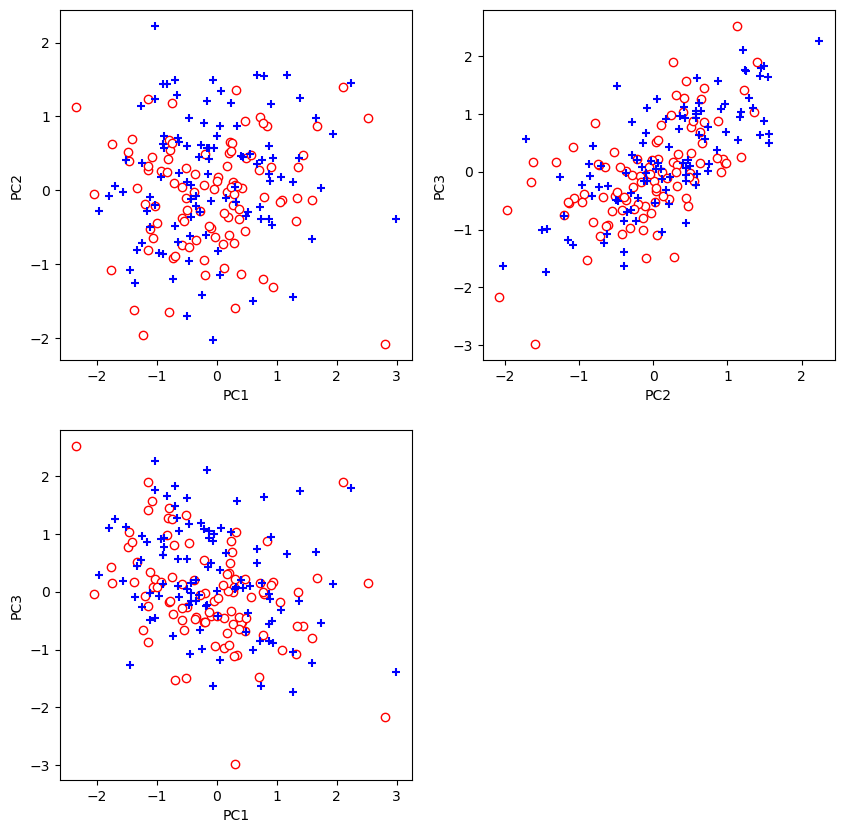

In [156]:
fig, axs = plt.subplots(2,2, figsize=(10, 10))
axs[0, 0].scatter(bank2vector[:100, 0], bank2vector[:100, 1], edgecolor='r', marker='o', facecolors='w')
axs[0, 0].scatter(bank2vector[100:, 0], bank2vector[100:, 1], c='b', marker='+')
axs[0, 0].set_xlabel('PC1')
axs[0, 0].set_ylabel('PC2')

axs[0, 1].scatter(bank2vector[:100, 1], bank2vector[:100, 2], edgecolor='r', marker='o', facecolors='w')
axs[0, 1].scatter(bank2vector[100:, 1], bank2vector[100:, 2], c='b', marker='+')
axs[0, 1].set_xlabel('PC2')
axs[0, 1].set_ylabel('PC3')

axs[1, 0].scatter(bank2vector[:100, 0], bank2vector[:100, 2], edgecolor='r', marker='o', facecolors= 'w')
axs[1, 0].scatter(bank2vector[100:, 0], bank2vector[100:, 2], c='b', marker='+')
axs[1, 0].set_xlabel('PC1')
axs[1, 0].set_ylabel('PC3')

axs[1, 1].axis('off')
plt.show()

---

# 🍲Food

In [157]:
foodheaders = ['Class', 'bread', 'vegetables', 'fruits', 'meat', 'poultry', 'milk', 'wine']
food = pd.read_csv("food.dat", sep = r"\s+", names=foodheaders, header=None)
food.head()

,Class,bread,vegetables,fruits,meat,poultry,milk,wine
0,MA2,332,428,354,1437,526,247,427
1,EM2,293,559,388,1527,567,239,258
2,CA2,372,767,562,1948,927,235,433
3,MA3,406,563,341,1507,544,324,407
4,EM3,386,608,396,1501,558,319,363


In [158]:
food.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Class       12 non-null     object
 1   bread       12 non-null     int64 
 2   vegetables  12 non-null     int64 
 3   fruits      12 non-null     int64 
 4   meat        12 non-null     int64 
 5   poultry     12 non-null     int64 
 6   milk        12 non-null     int64 
 7   wine        12 non-null     int64 
dtypes: int64(7), object(1)
memory usage: 900.0+ bytes


### PCA with 👇columns(variables) covariance

In [159]:
food = food.iloc[:, 1:8]

food_scaled = (food-food.mean())/food.std()
cov_matrix = np.cov(food_scaled, rowvar=False)
eigenvalue, eigenvector = np.linalg.eig(cov_matrix)
foodvector = np.dot(food_scaled, eigenvector)

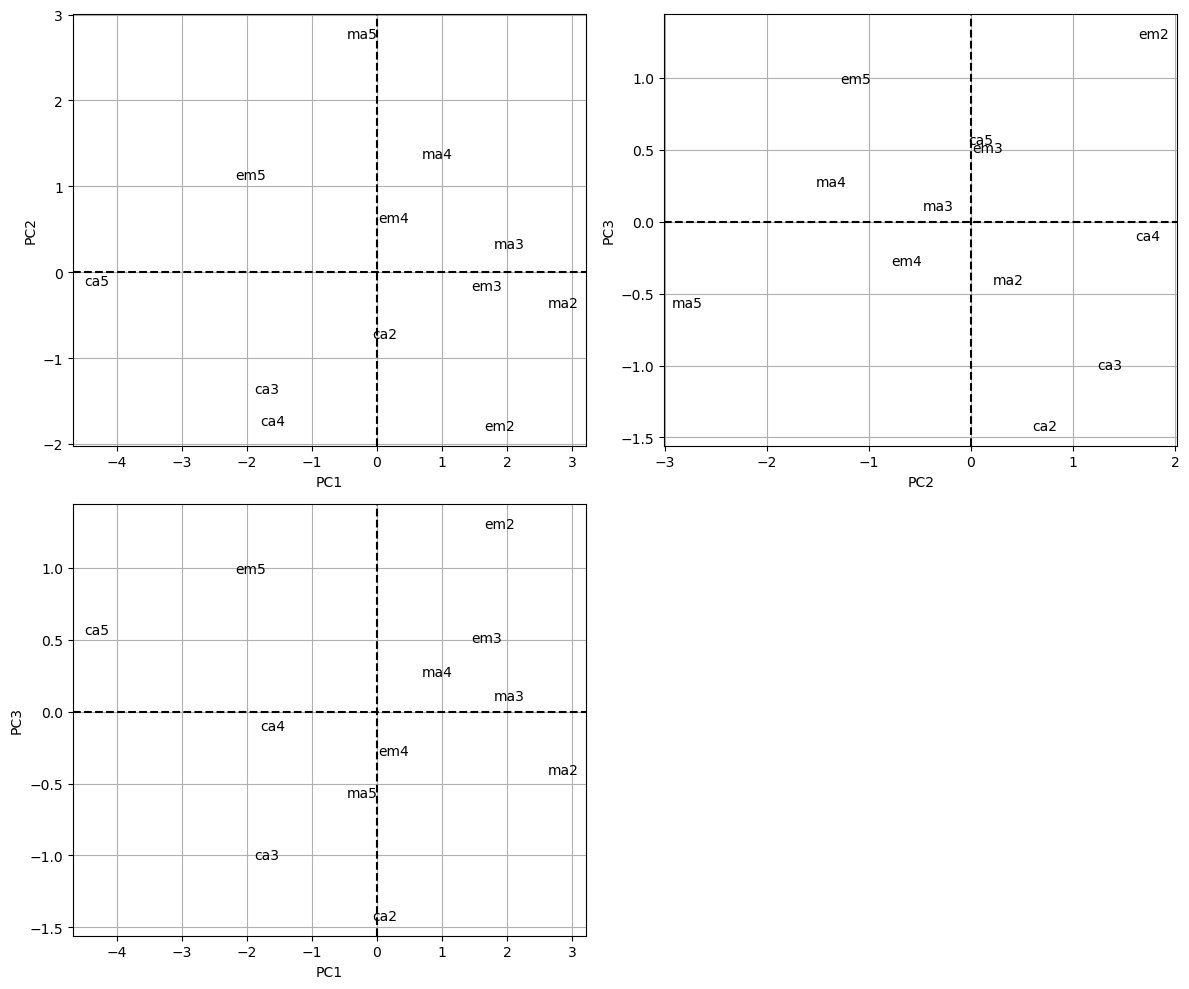

In [160]:
namesample = ["ma2", "em2", "ca2", "ma3", "em3", "ca3", "ma4", "em4", "ca4", "ma5", "em5", 
         "ca5"]
fig, axs = plt.subplots(2,2, figsize=(12, 10))

axs[0, 0].scatter(-foodvector[:, 0], foodvector[:, 1], alpha=0)
for i in range(len(namesample)):
    axs[0, 0].text(-foodvector[i, 0], foodvector[i, 1], namesample[i], ha='center', va='center')
axs[0, 0].set_xlabel('PC1')
axs[0, 0].set_ylabel('PC2')
axs[0, 0].axhline(y=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 0].axvline(x=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 0].grid(True)

axs[0, 1].scatter(-foodvector[:, 1], foodvector[:, 2], alpha=0)
for i in range(len(namesample)):
    axs[0, 1].text(-foodvector[i, 1], foodvector[i, 2], namesample[i], ha='center', va='center')
axs[0, 1].set_xlabel('PC2')
axs[0, 1].set_ylabel('PC3')
axs[0, 1].axhline(y=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 1].axvline(x=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 1].grid(True)

axs[1, 0].scatter(-foodvector[:, 0], foodvector[:, 2], alpha=0)
for i in range(len(namesample)):
    axs[1, 0].text(-foodvector[i, 0], foodvector[i, 2], namesample[i], ha='center', va='center')
axs[1, 0].set_xlabel('PC1')
axs[1, 0].set_ylabel('PC3')
axs[1, 0].axhline(y=0, color='k', linestyle='--', linewidth=1.5)
axs[1, 0].axvline(x=0, color='k', linestyle='--', linewidth=1.5)
axs[1, 0].grid(True)

axs[1, 1].axis('off')
plt.tight_layout()
plt.show()

In [161]:
sam_df = pd.DataFrame({'PC1': -foodvector.real[:, 0], 'PC2':foodvector.real[:, 1], 'PC3':foodvector.real[:, 2]})
sam_df['Sample'] = namesample
sam_df = sam_df[['Sample', 'PC1', 'PC2', 'PC3']]
print(sam_df)

   Sample       PC1       PC2       PC3
0     ma2  2.858696 -0.363576 -0.403709
1     em2  1.889239 -1.792236  1.306062
2     ca2  0.117899 -0.725509 -1.421708
3     ma3  2.040760  0.323306  0.106172
4     em3  1.694313 -0.162704  0.512888
5     ca3 -1.694298 -1.354887 -0.994991
6     ma4  0.932841  1.371702  0.275668
7     em4  0.252167  0.632497 -0.273362
8     ca4 -1.600518 -1.736013 -0.098484
9     ma5 -0.221028  2.776821 -0.567067
10    em5 -1.951164  1.131193  0.989434
11    ca5 -4.318908 -0.100593  0.569097


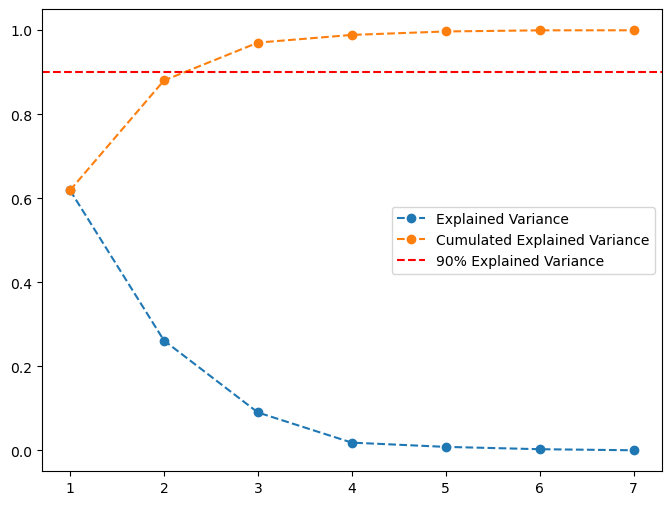

In [162]:
explained_variance_ratio = eigenvalue/np.sum(eigenvalue)
cumulative_variance = np.cumsum(explained_variance_ratio)
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, marker='o', linestyle='--', label='Explained Variance')
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--',label='Cumulated Explained Variance')
plt.axhline(y = 0.9, color = 'r', linestyle = '--', label = '90% Explained Variance')
plt.legend()
plt.show()

In [163]:
variance_df = pd.DataFrame({'eigenvalue': np.round(eigenvalue, 4),
                            'explained_variance_ratio': np.round(explained_variance_ratio, 4),
                            'cumulative_variance': np.round(cumulative_variance, 4)})
variance_df

,eigenvalue,explained_variance_ratio,cumulative_variance
0,4.3332,0.6190,0.6190
1,1.8303,0.2615,0.8805
2,0.6308,0.0901,0.9706
3,0.1283,0.0183,0.9890
4,0.0576,0.0082,0.9972
5,0.0188,0.0027,0.9999
6,0.0009,0.0001,1.0000


In [217]:
food_scaled = (food-food.mean())/food.std()
cov_matrix2 = np.cov(food_scaled, rowvar=True)
eigenvalue2, eigenvector2 = np.linalg.eig(cov_matrix2)
foodvector2 = np.dot(food_scaled.T, eigenvector2)

c:\Users\USER\anaconda3\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\USER\anaconda3\Lib\site-packages\matplotlib\collections.py:197: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)
c:\Users\USER\anaconda3\Lib\site-packages\matplotlib\text.py:897: ComplexWarning: Casting complex values to real discards the imaginary part
  x = float(self.convert_xunits(self._x))
c:\Users\USER\anaconda3\Lib\site-packages\matplotlib\text.py:898: ComplexWarning: Casting complex values to real discards the imaginary part
  y = float(self.convert_yunits(self._y))
c:\Users\USER\anaconda3\Lib\site-packages\matplotlib\text.py:756: ComplexWarning: Casting complex values to real discards the imaginary part
  posx = float(self.convert_xunits(self._x))
c:\Users\USER\anaconda3\Lib\site-packages\matplotlib\text.py:757: ComplexWarning: Casti

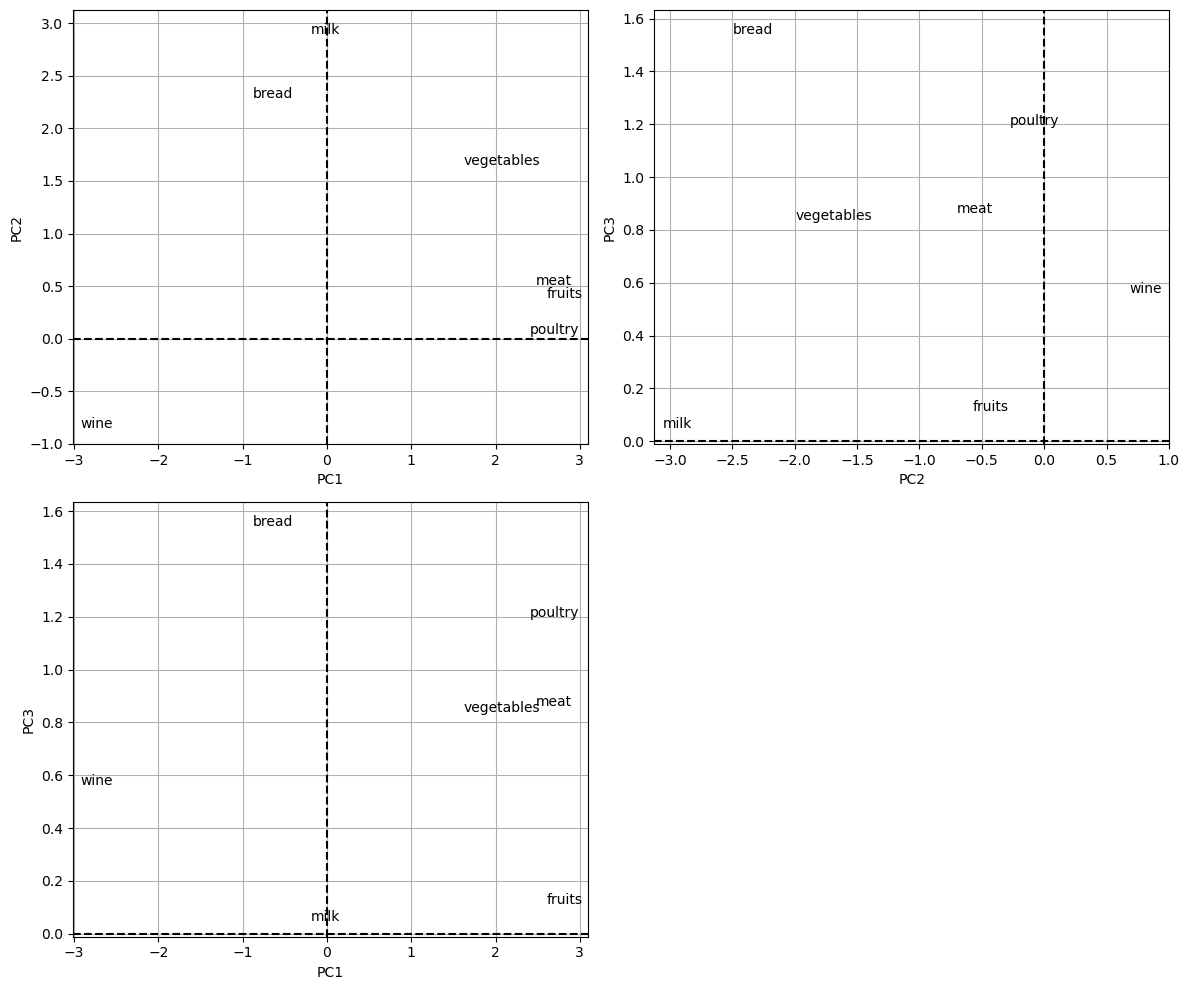

In [218]:
namevariable = ['bread', 'vegetables', 'fruits', 'meat', 'poultry', 'milk', 'wine']

fig, axs = plt.subplots(2,2, figsize=(12, 10))

axs[0, 0].scatter(-foodvector2[:, 0], foodvector2[:, 1], alpha=0)
for i in range(len(namevariable)):
    axs[0, 0].text(-foodvector2[i, 0], foodvector2[i, 1], namevariable[i], ha='center', va='center')
axs[0, 0].set_xlabel('PC1')
axs[0, 0].set_ylabel('PC2')
axs[0, 0].axhline(y=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 0].axvline(x=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 0].grid(True)

axs[0, 1].scatter(-foodvector2[:, 1], foodvector2[:, 2], alpha=0)
for i in range(len(namevariable)):
    axs[0, 1].text(-foodvector2[i, 1], foodvector2[i, 2], namevariable[i], ha='center', va='center')
axs[0, 1].set_xlabel('PC2')
axs[0, 1].set_ylabel('PC3')
axs[0, 1].axhline(y=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 1].axvline(x=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 1].grid(True)

axs[1, 0].scatter(-foodvector2[:, 0], foodvector2[:, 2], alpha=0)
for i in range(len(namevariable)):
    axs[1, 0].text(-foodvector2[i, 0], foodvector2[i, 2], namevariable[i], ha='center', va='center')
axs[1, 0].set_xlabel('PC1')
axs[1, 0].set_ylabel('PC3')
axs[1, 0].axhline(y=0, color='k', linestyle='--', linewidth=1.5)
axs[1, 0].axvline(x=0, color='k', linestyle='--', linewidth=1.5)
axs[1, 0].grid(True)

axs[1, 1].axis('off')
plt.tight_layout()
plt.show()

### Using PCA package

In [166]:
scaler = StandardScaler()
food_scaled_ = scaler.fit_transform(food)
pca = PCA(n_components=3)
z = pca.fit_transform(food_scaled_)
z_df = pd.DataFrame(z, columns=['PC1', 'PC2', 'PC3'])
z_df['Name'] = namesample
z_df = z_df[['Name', 'PC1', 'PC2', 'PC3']]
z_df

,Name,PC1,PC2,PC3
0,ma2,-2.985810,-0.379743,0.421660
1,em2,-1.973246,-1.871930,-1.364137
2,ca2,-0.123142,-0.757770,1.484926
3,ma3,-2.131504,0.337682,-0.110893
4,em3,-1.769652,-0.169939,-0.535694
5,ca3,1.769636,-1.415133,1.039234
6,ma4,-0.974321,1.432696,-0.287926
7,em4,-0.263380,0.660621,0.285517
8,ca4,1.671687,-1.813206,0.102863
9,ma5,0.230856,2.900295,0.592282


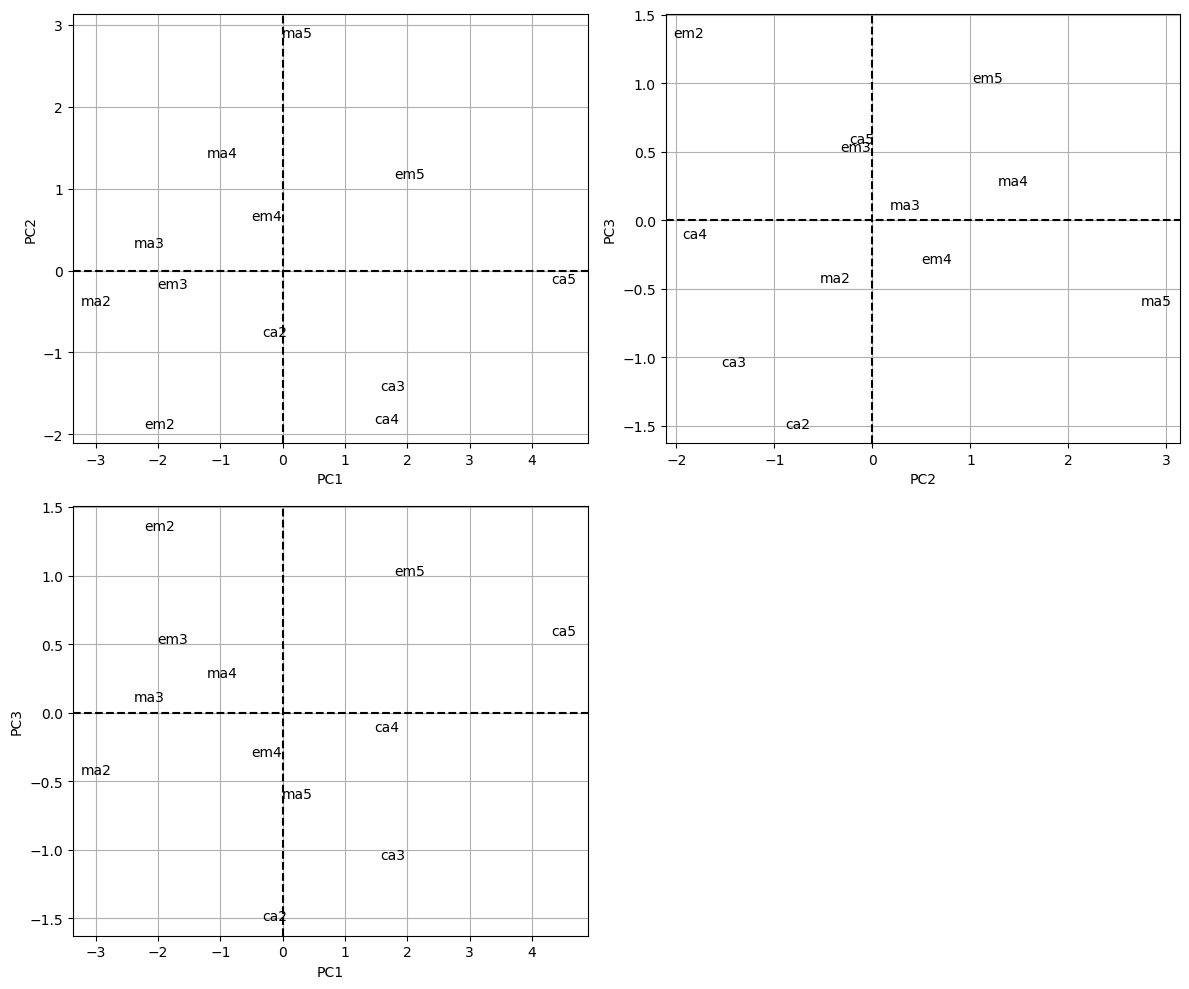

In [167]:
# plt.figure(figsize=(8, 6))
# plt.scatter(z[:, 0], z[:, 1], alpha=0)
# for i in range(0, len(z)):
#     plt.text(z[i, 0], z[i, 1], namesample[i], ha='center', va='center')
# plt.axhline(y=0, color='k', linestyle='--', linewidth=1.5)
# plt.axvline(x=0, color='k', linestyle='--', linewidth=1.5)
# plt.grid(True)
# plt.show()


fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].scatter(z[:, 0], z[:, 1], alpha=0)
for i in range(len(namesample)):
    axs[0, 0].text(z[i, 0], z[i, 1], namesample[i], ha='center', va='center')
axs[0, 0].set_xlabel('PC1')
axs[0, 0].set_ylabel('PC2')
axs[0, 0].axhline(y=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 0].axvline(x=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 0].grid(True)

axs[0, 1].scatter(z[:, 1], -z[:, 2], alpha=0)
for i in range(len(namesample)):
    axs[0, 1].text(z[i, 1], -z[i, 2], namesample[i], ha='center', va='center')
axs[0, 1].set_xlabel('PC2')
axs[0, 1].set_ylabel('PC3')
axs[0, 1].axhline(y=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 1].axvline(x=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 1].grid(True)

axs[1, 0].scatter(z[:, 0], -z[:, 2], alpha=0)
for i in range(len(namesample)):
    axs[1, 0].text(z[i, 0], -z[i, 2], namesample[i], ha='center', va='center')
axs[1, 0].set_xlabel('PC1')
axs[1, 0].set_ylabel('PC3')
axs[1, 0].axhline(y=0, color='k', linestyle='--', linewidth=1.5)
axs[1, 0].axvline(x=0, color='k', linestyle='--', linewidth=1.5)
axs[1, 0].grid(True)

axs[1, 1].axis('off')
plt.tight_layout()
plt.show()

---

### PCA with 👉rows(samples) covariance

In [168]:
food_scaled2 = (food.T-food.T.mean())/food.T.std()
sampled_cov_matrix = np.cov(food_scaled2, rowvar=False)
eigenvalue3, eigenvector3 = np.linalg.eig(sampled_cov_matrix)
sam_foodvector = np.dot(food_scaled2, eigenvector3)

c:\Users\USER\anaconda3\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\USER\anaconda3\Lib\site-packages\matplotlib\collections.py:197: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)
c:\Users\USER\anaconda3\Lib\site-packages\matplotlib\text.py:897: ComplexWarning: Casting complex values to real discards the imaginary part
  x = float(self.convert_xunits(self._x))
c:\Users\USER\anaconda3\Lib\site-packages\matplotlib\text.py:898: ComplexWarning: Casting complex values to real discards the imaginary part
  y = float(self.convert_yunits(self._y))
c:\Users\USER\anaconda3\Lib\site-packages\matplotlib\text.py:756: ComplexWarning: Casting complex values to real discards the imaginary part
  posx = float(self.convert_xunits(self._x))
c:\Users\USER\anaconda3\Lib\site-packages\matplotlib\text.py:757: ComplexWarning: Casti

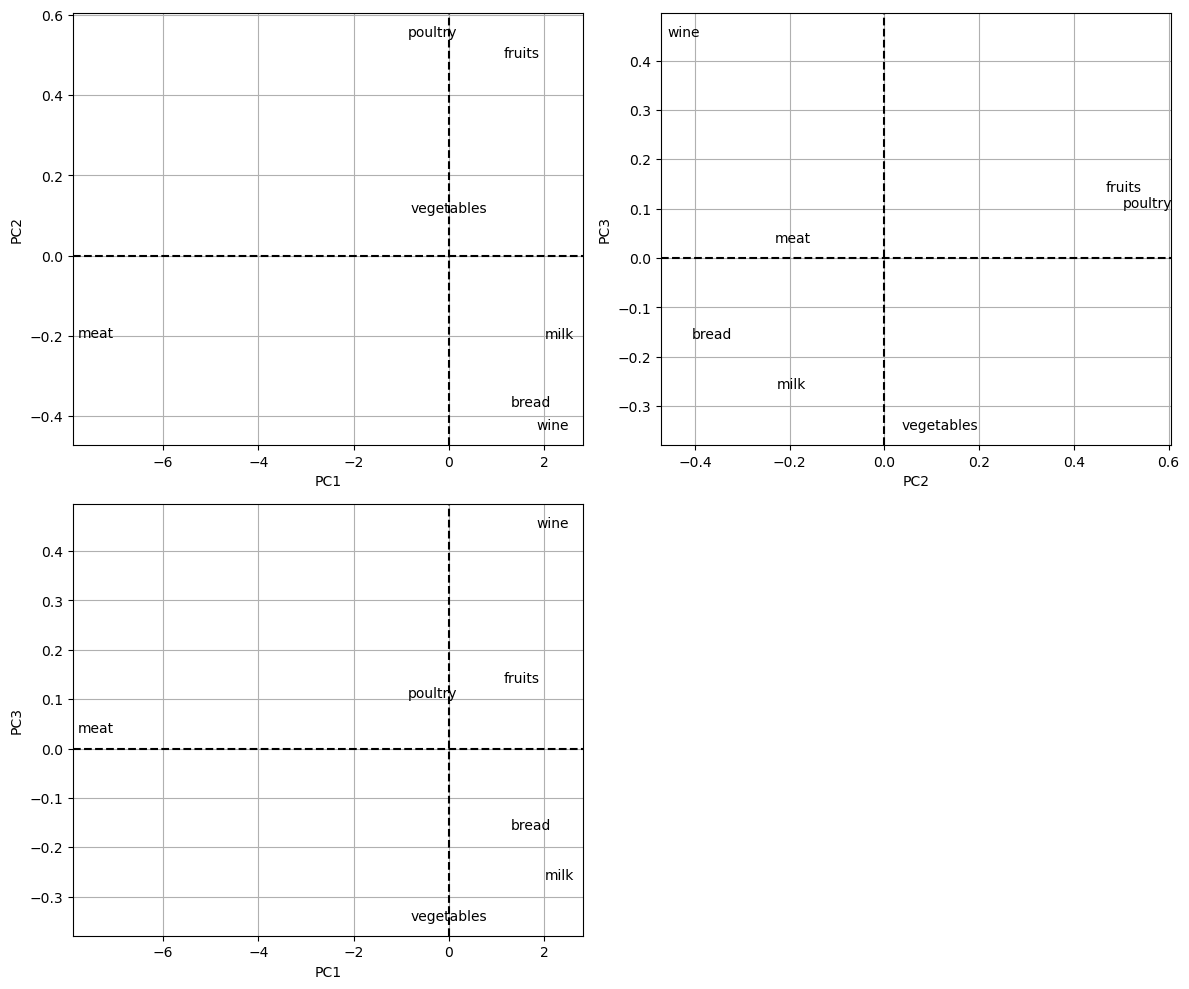

In [171]:
namevariable = ['bread', 'vegetables', 'fruits', 'meat', 'poultry', 'milk', 'wine']
fig, axs = plt.subplots(2,2, figsize=(12, 10))

axs[0, 0].scatter(sam_foodvector[:, 0], sam_foodvector[:, 1], alpha=0)
for i in range(len(namevariable)):
    axs[0, 0].text(sam_foodvector[i, 0], sam_foodvector[i, 1], namevariable[i], ha='center', va='center')
axs[0, 0].set_xlabel('PC1')
axs[0, 0].set_ylabel('PC2')
axs[0, 0].axhline(y=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 0].axvline(x=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 0].grid(True)

axs[0, 1].scatter(sam_foodvector[:, 1], sam_foodvector[:, 2], alpha=0)
for i in range(len(namevariable)):
    axs[0, 1].text(sam_foodvector[i, 1], sam_foodvector[i, 2], namevariable[i], ha='center', va='center')
axs[0, 1].set_xlabel('PC2')
axs[0, 1].set_ylabel('PC3')
axs[0, 1].axhline(y=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 1].axvline(x=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 1].grid(True)

axs[1, 0].scatter(sam_foodvector[:, 0], sam_foodvector[:, 2], alpha=0)
for i in range(len(namevariable)):
    axs[1, 0].text(sam_foodvector[i, 0], sam_foodvector[i, 2], namevariable[i], ha='center', va='center')
axs[1, 0].set_xlabel('PC1')
axs[1, 0].set_ylabel('PC3')
axs[1, 0].axhline(y=0, color='k', linestyle='--', linewidth=1.5)
axs[1, 0].axvline(x=0, color='k', linestyle='--', linewidth=1.5)
axs[1, 0].grid(True)

axs[1, 1].axis('off')
plt.tight_layout()
plt.show()

In [226]:
food_scaled2 = (food.T-food.T.mean())/food.T.std()
sampled_cov_matrix2 = np.cov(food_scaled2.T, rowvar=False)
eigenvalue2, eigenvector2 = np.linalg.eig(sampled_cov_matrix2)
sam_foodvector2 = np.dot(food_scaled2.T, eigenvector2)

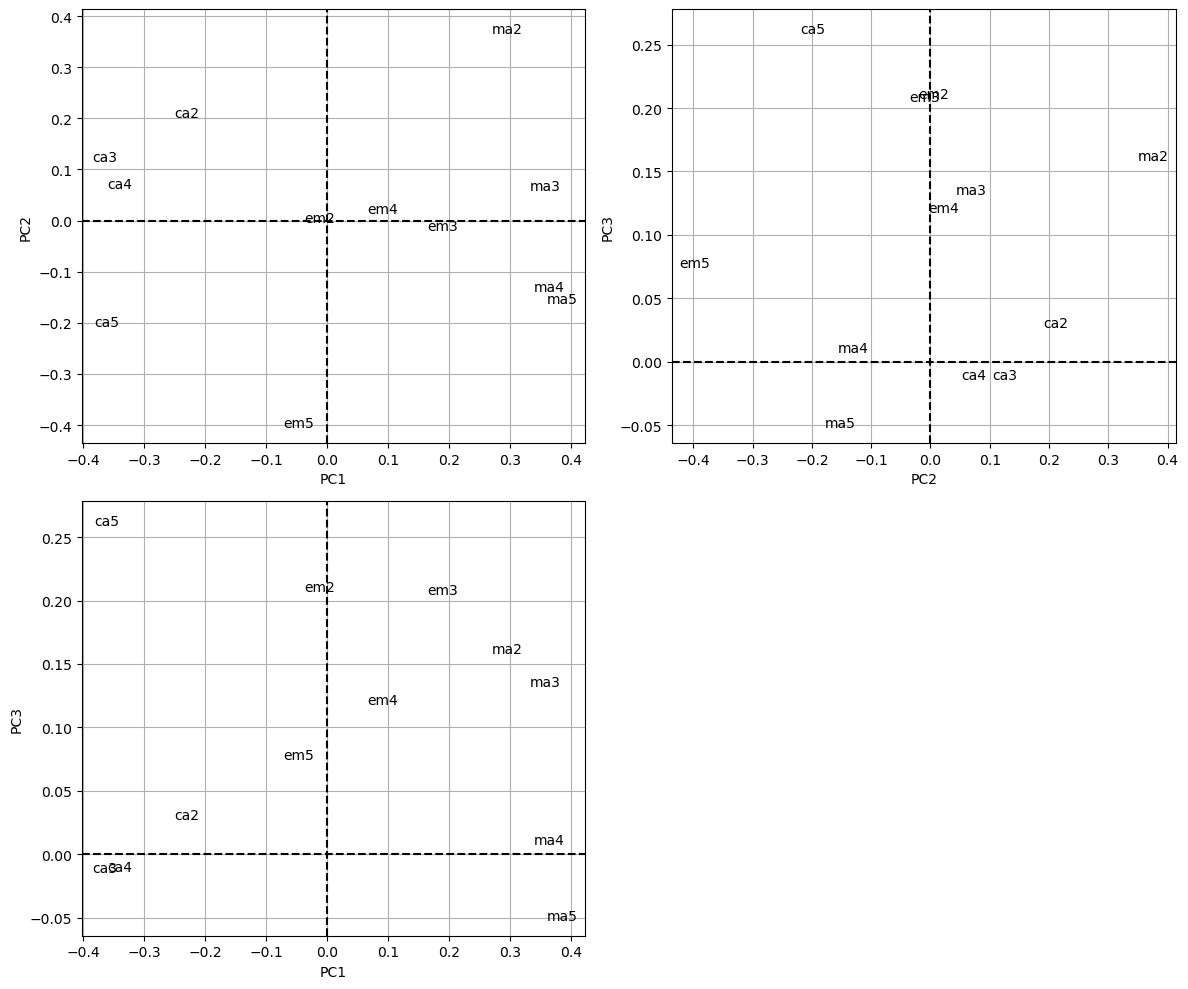

In [227]:
namesample = ["ma2", "em2", "ca2", "ma3", "em3", "ca3", "ma4", "em4", "ca4", "ma5", "em5", 
         "ca5"]
fig, axs = plt.subplots(2,2, figsize=(12, 10))

axs[0, 0].scatter(sam_foodvector2[:, 0], sam_foodvector2[:, 1], alpha=0)
for i in range(len(namesample)):
    axs[0, 0].text(sam_foodvector2[i, 0], sam_foodvector2[i, 1], namesample[i], ha='center', va='center')
axs[0, 0].set_xlabel('PC1')
axs[0, 0].set_ylabel('PC2')
axs[0, 0].axhline(y=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 0].axvline(x=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 0].grid(True)

axs[0, 1].scatter(sam_foodvector2[:, 1], sam_foodvector2[:, 2], alpha=0)
for i in range(len(namesample)):
    axs[0, 1].text(sam_foodvector2[i, 1], sam_foodvector2[i, 2], namesample[i], ha='center', va='center')
axs[0, 1].set_xlabel('PC2')
axs[0, 1].set_ylabel('PC3')
axs[0, 1].axhline(y=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 1].axvline(x=0, color='k', linestyle='--', linewidth=1.5)
axs[0, 1].grid(True)

axs[1, 0].scatter(sam_foodvector2[:, 0], sam_foodvector2[:, 2], alpha=0)
for i in range(len(namesample)):
    axs[1, 0].text(sam_foodvector2[i, 0], sam_foodvector2[i, 2], namesample[i], ha='center', va='center')
axs[1, 0].set_xlabel('PC1')
axs[1, 0].set_ylabel('PC3')
axs[1, 0].axhline(y=0, color='k', linestyle='--', linewidth=1.5)
axs[1, 0].axvline(x=0, color='k', linestyle='--', linewidth=1.5)
axs[1, 0].grid(True)

axs[1, 1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
var_real = sam_foodvector.T.real
var_df = pd.DataFrame({'PC1': sam_foodvector.T.real[:, 0], 'PC2': sam_foodvector.T.real[:, 1], 'PC3': sam_foodvector.T.real[:, 2]})
var_df['Variable'] = namevariable
var_df = var_df[['Variable', 'PC1', 'PC2', 'PC3']]
print(var_df)

In [ ]:
explained_variance_ratio2 = eigenvalue2/np.sum(eigenvalue2).real
cumulative_variance2 = np.cumsum(explained_variance_ratio2).real
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance_ratio2)+1), explained_variance_ratio2, marker='o', linestyle='--', label='Explained Variance')
plt.plot(range(1, len(cumulative_variance2)+1), cumulative_variance2, marker='o', linestyle='--',label='Cumulated Explained Variance')
plt.axhline(y = 0.9, color = 'r', linestyle = '--', label = '90% Explained Variance')
plt.legend()
plt.show()

In [ ]:
variance_df2 = pd.DataFrame({'eigenvalue': np.round(eigenvalue2.real, 4),
                            'explained_variance_ratio': np.round(explained_variance_ratio2.real, 4),
                            'cumulative_variance': np.round(cumulative_variance2, 4)})
variance_df2

---

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
C:\Users\USER\AppData\Local\Temp\ipykernel_5332\3689464687.py:5: SyntaxWarning: invalid escape sequence '\s'
  x = pd.read_csv("food.dat", sep = "\s+", header=None)
c:\Users\USER\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


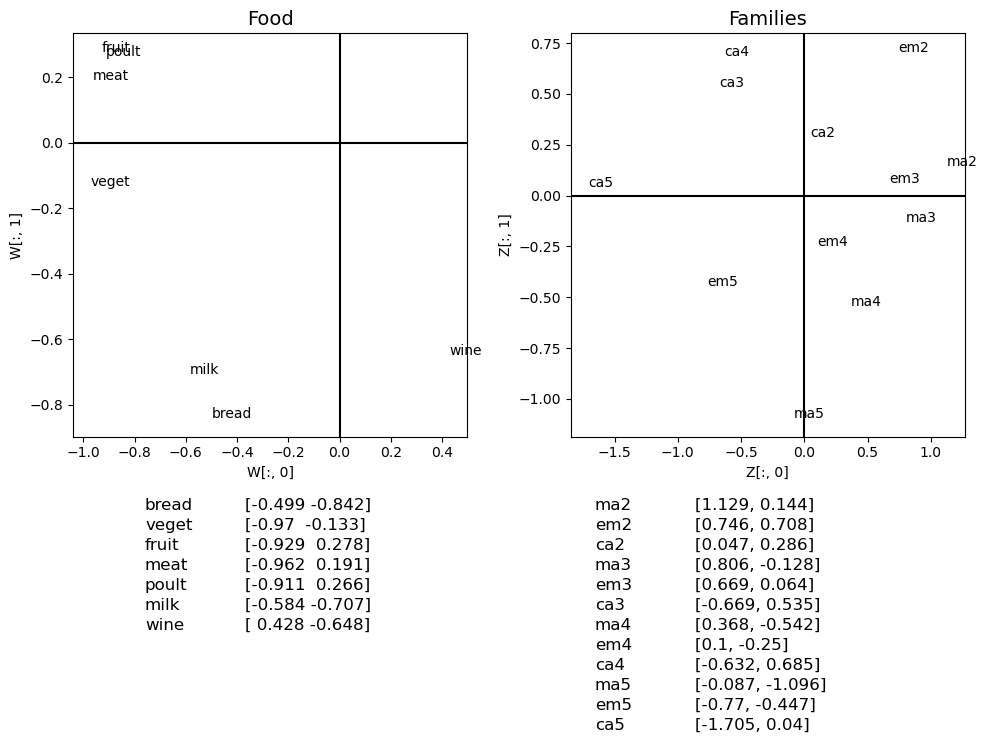

In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

x = pd.read_csv("food.dat", sep = "\s+", header=None)

x = x.iloc[:, 1:len(x.columns)]
one = np.full((len(x), len(x)), 1)
h = np.diag([1]*len(x)) - one/len(x)
a = x - np.tile(np.array(x.mean()), (len(x), 1))
d = np.diag(1/np.sqrt(np.sum(a**2)/len(x)))

xs = h @ x @ d
xs1 = xs/np.sqrt(len(x))
xs2 = xs1.T @ xs1

Lambda, gamma = np.linalg.eig(xs2)
w = gamma * np.tile(np.sqrt(Lambda), (len(gamma), 1))
w = np.round(w[:, :2], 3)

z1 = xs1 @ gamma
z2 = np.sqrt(len(x)/len(x.columns)) * z1
z = np.round(z2.iloc[:, :2], 3)

namew = ["bread", "veget", "fruit", "meat", "poult", "milk", "wine"]
namez = ["ma2", "em2", "ca2", "ma3", "em3", "ca3", "ma4", "em4", "ca4", "ma5", "em5", 
         "ca5"]

fig, axes = plt.subplots(1, 2, figsize = (10, 5))

axes[0].scatter(w[:, 0], w[:, 1], c = "w")
for i in range(0, len(namew)):
    axes[0].text(w[i, 0], w[i, 1], namew[i])

axes[0].set_xlabel("W[:, 0]")
axes[0].set_ylabel("W[:, 1]")
axes[0].axvline(0, c = "k")
axes[0].axhline(0, c = "k")
axes[0].set_title("Food", fontsize = 14)
for i in range(0, len(namew)):
    fig.text(0.15, -0.03-(0.04*i), namew[i], fontsize = 12)
    fig.text(0.25, -0.03-(0.04*i), w[i], fontsize = 12)
    
axes[1].scatter(z.iloc[:, 0], z.iloc[:, 1], c = "w")
for i in range(0, len(namez)):
    axes[1].text(z.iloc[i, 0], z.iloc[i, 1], namez[i])

axes[1].set_xlabel("Z[:, 0]")
axes[1].set_ylabel("Z[:, 1]")
axes[1].axvline(0, c = "k")
axes[1].axhline(0, c = "k")
axes[1].set_title("Families", fontsize = 14)
for i in range(0, len(namez)):
    fig.text(0.6, -0.03-(0.04*i), namez[i], fontsize = 12)
    fig.text(0.7, -0.03-(0.04*i), [z.iloc[i, 0], z.iloc[i, 1]], fontsize = 12)

plt.tight_layout()
plt.show()
